In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

!pip install tiktoken
import tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 995.3/995.3 kB 1.1 MB/s eta 0:00:00a 0:00:01m


In [2]:
# GPT-4's tokenizer
tokenizer = tiktoken.get_encoding('cl100k_base')

In [3]:
import requests
import re
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = tokenizer.encode(text)

In [ ]:
# split by punctuation
words = re.split(r'([,.:;—?_!"“()\']|--|\s)',text)
words = [item.strip() for item in words if item.strip()]

tokenCount = np.zeros((len(words),2),dtype=int)

for idx,w in enumerate(words):
  tokenCount[idx,0] = len(w) # first column is the length of the word
  tokenCount[idx,1] = len(tokenizer.encode(w)) # second column is the number of tokens

In [ ]:
plt.figure(figsize=(12,4))

offsetsX = np.random.randn(len(words))/20
offsetsY = np.random.randn(len(words))/20

plt.plot(tokenCount[:,0]+offsetsX,tokenCount[:,1]+offsetsY,'k.',alpha=.5)
plt.gca().set(xlabel='Word lengths',ylabel='Encoded token count',xticks=np.arange(1,np.max(tokenCount[:,0])+1))

plt.show()

In [ ]:
# find words with characters
wordsWith14Chars = np.where(tokenCount[:,0]==14)[0]

print(wordsWith14Chars)

# print their tokens
for idx in wordsWith14Chars:
  this_decode = [ tokenizer.decode([t]) for t in tokenizer.encode(words[idx]) ]
  print(f'"{words[idx]}" comprises {this_decode}')

In [ ]:
# "more efficient" word: lots of letters and few tokens
# "less efficient" word: few letters and many tokens
moreEfficient = np.where( (tokenCount[:,0]==17) & (tokenCount[:,1]==2) )[0]
lessEfficient = np.where( (tokenCount[:,0]==10) & (tokenCount[:,1]==6) )[0]

print(f'A very efficient word:\n  "{words[moreEfficient[0]]}" has {tokenCount[moreEfficient[0],0]} letters and {tokenCount[moreEfficient[0],1]} tokens.\n')
print(f'An inefficient word:\n  "{words[lessEfficient[0]]}" has {tokenCount[lessEfficient[0],0]} letters and {tokenCount[lessEfficient[0],1]} tokens.')

[3.  5.  2.  ... 2.5 2.  3. ]


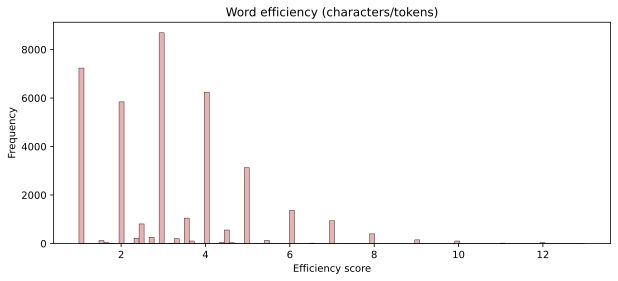

In [ ]:
# "efficiency" as characters/tokens
efficiency = tokenCount[:,0]/tokenCount[:,1]

# show a historgram
plt.figure(figsize=(10,4))
plt.hist(efficiency,color=[.9,.7,.7],edgecolor='k',linewidth=.4,bins='fd')
plt.gca().set(xlabel='Efficiency score',ylabel='Frequency',title='Word efficiency (characters/tokens)')
plt.show()

In [ ]:
# find the most and least efficiently tokenized words
max_efficiency = np.max(efficiency)
min_efficiency = np.min(efficiency)

# find all the words with those efficiency values
most_efficient_words = np.where(efficiency==max_efficiency)[0]
least_efficient_words = np.where(efficiency==min_efficiency)[0]

# find and print the unique words with max-efficiency score
most_efficient_words = list(set([ words[i] for i in most_efficient_words ]))

print('MOST EFFICIENT WORDS:')
for w in most_efficient_words:
  print(f'"{w}" has {max_efficiency} characters per token')


# repeat for min-efficiency score
print('\n\nLEAST EFFICIENT WORDS:')
for w in list(set([ words[i] for i in least_efficient_words ])):
  print(f'"{w}" has {min_efficiency:.2f} characters per token')

In [12]:
# unique set of words as we've split them up
uniqueWords = set(words)
print(f'There are {len(uniqueWords)} unique words in The Time Machine according to our split.')

There are 5007 unique words in The Time Machine according to our split.


In [ ]:
# random token
token_idx = np.random.randint(0,tokenizer.n_vocab//10)
print(token_idx)

# non-random tokens to try
# token_idx = 1879#,5030#,716

# find the words (from our split) in The Time Machine that contain that token
words_with_token = [w for w in uniqueWords if token_idx in tokenizer.encode(w)]
print(words_with_token)

# find the context (from the full encoding) surrounding each token appearance
seqs_with_token = np.array(tmTokens)==token_idx

# print the token
print(f'Token {token_idx} is "{tokenizer.decode([token_idx])}"\n\n')

# its occurance in our manually split words
print(f'*** Our manual word split: Token appears {len(words_with_token)} times, including:\n----------------')
for w in words_with_token:
  print(f'{w}')

# its occurances in the GPT encoding
print(f'\n\n*** From encoding the full text: This token appears {sum(seqs_with_token)} times, including:\n----------------')
for s in np.where(seqs_with_token)[0]:
  print(f'{tokenizer.decode( np.array(tmTokens[s-5:s+5]) )}\n----------------')

In [21]:
# the unique words, as a list instead of a set (for indexing)
uniqueWords = list(uniqueWords)

# initialize results vectors
wordFreq = np.zeros(len(uniqueWords),dtype=int)
numTokens = np.zeros(len(uniqueWords),dtype=int)


# loop through all unique words
for i,uword in enumerate(uniqueWords):

  # count the number of times that word appears
  wordFreq[i] = words.count(uword)

  # count the number of tokens in that word
  numTokens[i] = len(tokenizer.encode(uword))

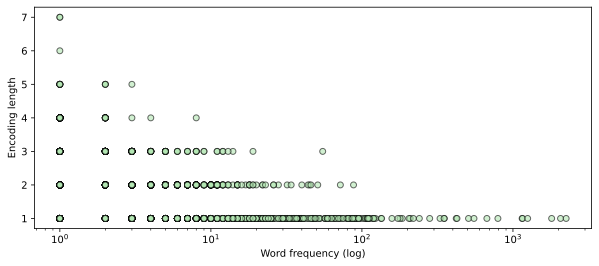

In [22]:
plt.figure(figsize=(10,4))
plt.plot(wordFreq,numTokens,'ko',markerfacecolor=[.7,.9,.7],alpha=.6)
plt.gca().set(xlabel='Word frequency (log)',ylabel='Encoding length',xscale='log')
plt.show()

In [23]:
wordFreqidx = np.argsort(wordFreq)[::-1]
for i in wordFreqidx[:20]:
  print(f'{wordFreq[i]:>5,} appearances of "{uniqueWords[i]}"')

2,250 appearances of ","
2,066 appearances of "the"
1,804 appearances of "."
1,251 appearances of "I"
1,157 appearances of "of"
1,150 appearances of "and"
  795 appearances of "a"
  672 appearances of "to"
  552 appearances of "was"
  508 appearances of "in"
  426 appearances of "my"
  421 appearances of "that"
  351 appearances of "“"
  350 appearances of "had"
  329 appearances of "it"
  281 appearances of "me"
  240 appearances of "as"
  219 appearances of "The"
  209 appearances of "with"
  205 appearances of "at"
